In [15]:
import os
import sys
import pandas as pd
import numpy as np
import missingno
import csv

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)

from utils import *

In [16]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [17]:
base_path = f'../../data/{NUTS2}/results/'

In [18]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['IT_Veneto_Results_2008-2019.csv',
 'IT_Veneto_Results_2023-August-1st_(new).csv',
 'IT_Veneto_Results_2023-August-2nd_(new).csv',
 'IT_Veneto_Results_2023-July-1st.csv',
 'IT_Veneto_Results_2023-July-1st_(new).csv',
 'IT_Veneto_Results_2023-July-2nd.csv',
 'IT_Veneto_Results_2023-July-2nd_(new).csv',
 'IT_Veneto_Results_2023-June-1st.csv',
 'IT_Veneto_Results_2023-June-1st_(new).csv',
 'IT_Veneto_Results_2023-June-2nd.csv',
 'IT_Veneto_Results_2023-June-2nd_(new).csv',
 'IT_Veneto_Results_2023-May-1st.csv',
 'IT_Veneto_Results_2023-May-1st_(new).csv',
 'IT_Veneto_Results_2023-May-2nd.csv',
 'IT_Veneto_Results_2023-May-2nd_(new).csv']

In [19]:
del file_list[1:3]

In [20]:
file_list

['IT_Veneto_Results_2008-2019.csv',
 'IT_Veneto_Results_2023-July-1st.csv',
 'IT_Veneto_Results_2023-July-1st_(new).csv',
 'IT_Veneto_Results_2023-July-2nd.csv',
 'IT_Veneto_Results_2023-July-2nd_(new).csv',
 'IT_Veneto_Results_2023-June-1st.csv',
 'IT_Veneto_Results_2023-June-1st_(new).csv',
 'IT_Veneto_Results_2023-June-2nd.csv',
 'IT_Veneto_Results_2023-June-2nd_(new).csv',
 'IT_Veneto_Results_2023-May-1st.csv',
 'IT_Veneto_Results_2023-May-1st_(new).csv',
 'IT_Veneto_Results_2023-May-2nd.csv',
 'IT_Veneto_Results_2023-May-2nd_(new).csv']

In [21]:
del file_list[2:16:2]

In [22]:
file_list

['IT_Veneto_Results_2008-2019.csv',
 'IT_Veneto_Results_2023-July-1st.csv',
 'IT_Veneto_Results_2023-July-2nd.csv',
 'IT_Veneto_Results_2023-June-1st.csv',
 'IT_Veneto_Results_2023-June-2nd.csv',
 'IT_Veneto_Results_2023-May-1st.csv',
 'IT_Veneto_Results_2023-May-2nd.csv']

In [23]:
result_files = []

for file in file_list:
    data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
    result_files.append(data)

In [32]:
#modifications

result_files[0].drop(columns=['x', 'y', 'case'], inplace=True)
result_files[1].drop(columns=['x', 'y'], inplace=True)
result_files[1].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[2].drop(columns=['x', 'y', 'Class Number - (Relative Risk Level)', 'Class Number - (Risk Level)'], inplace=True)
result_files[2].rename(columns={"probability": "score"}, inplace=True)
result_files[3].drop(columns=['x', 'y'], inplace=True)
result_files[3].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[4].drop(columns=['x', 'y'], inplace=True)
result_files[4].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[5].drop(columns=['x', 'y'], inplace=True)
result_files[5].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)
result_files[6].drop(columns=['x', 'y'], inplace=True)
result_files[6].rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)


In [33]:
concated = pd.concat(result_files, ignore_index=True, axis = 0)

<AxesSubplot:>

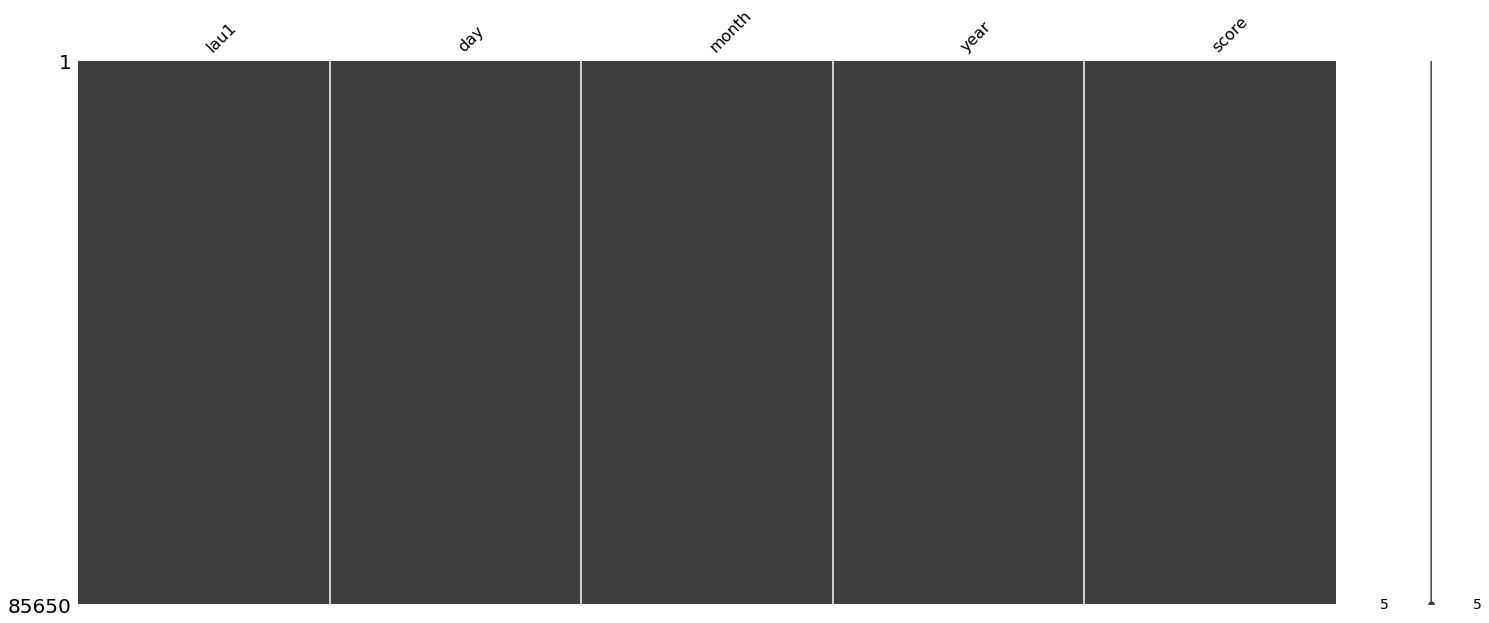

In [34]:
missingno.matrix(concated)

In [35]:
days = np.sort(concated.day.unique())
days

array([ 1, 16], dtype=int64)

In [36]:
months = np.sort(concated.month.unique())
months

array([ 5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [37]:
years = np.sort(concated.year.unique())
years

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2023], dtype=int64)

In [38]:
df = concated[(concated['month'] >= 5) & (concated['month'] <= 7)].copy()

In [39]:
df

,lau1,day,month,year,score
16,noventa da piave,16,7,2018,9.957754e-01
21,motta da livenza,16,7,2018,9.950087e-01
40,padova,16,7,2018,9.932722e-01
61,fontaniva,16,7,2018,9.917224e-01
77,caorle,16,7,2018,9.898940e-01
...,...,...,...,...,...
85645,rocca pietore,16,5,2023,3.882467e-12
85646,livinallongo da col da lana,16,5,2023,1.708339e-12
85647,selva da cadore,16,5,2023,1.447478e-12
85648,asiago,16,5,2023,1.547656e-13


In [40]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_2023.csv'

bins = []

with open(bins_path, mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        bins.extend(map(float, row))

print(bins)

[0.0, 0.2916874171585726, 0.7128345091584661, 0.8345479844283598, 0.9597101609376664, 0.983219513129097, 1.0]


In [41]:
df['risk_class'] = pd.cut(df['score'], bins=bins, labels=False, include_lowest=True)
df.head(10)

,lau1,day,month,year,score,risk_class
16,noventa da piave,16,7,2018,0.995775,5
21,motta da livenza,16,7,2018,0.995009,5
40,padova,16,7,2018,0.993272,5
61,fontaniva,16,7,2018,0.991722,5
77,caorle,16,7,2018,0.989894,5
107,ceggia,16,7,2018,0.987288,5
114,saint giustina in colle,16,7,2018,0.986820,5
128,dolo,16,7,2018,0.985645,5
138,mogliano veneto,16,7,2018,0.985160,5
140,trebaseleghe,16,7,2018,0.985105,5


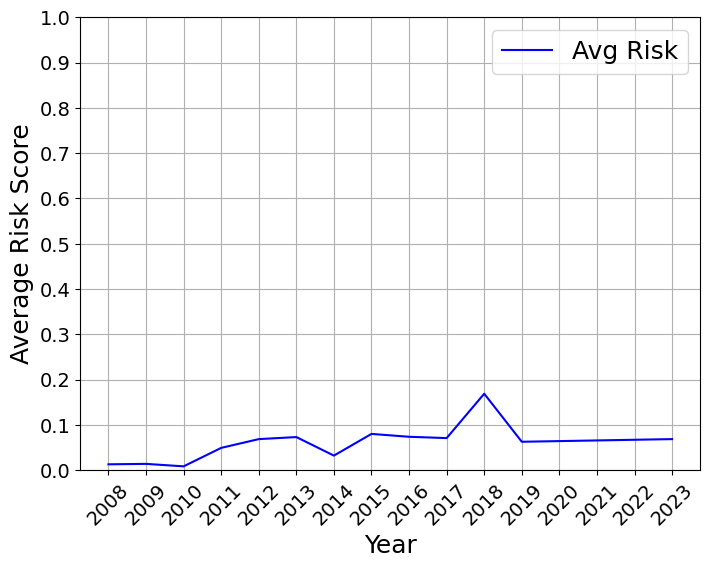

In [42]:
plot_trend_curve(df, plot_max = False, score_col = 'score', plot_cases=False, y_label='Average Risk Score')

In [43]:
risk_2022_over_7 = df[(df['year'] == 2022) & (df['risk_class'] >= 4)].copy()
risk_2022_over_7.reset_index(drop = True, inplace = True)
risk_2022_over_7

,lau1,day,month,year,score,risk_class


In [44]:
risk_2023_over_7 = df[(df['year'] == 2023) & (df['risk_class'] >= 4)].copy()
risk_2023_over_7.reset_index(drop = True, inplace = True)
risk_2023_over_7

,lau1,day,month,year,score,risk_class
0,codevigo,1,7,2023,0.991697,5
1,chioggia,1,7,2023,0.990341,5
2,venezia,1,7,2023,0.984115,5
3,chioggia,16,7,2023,0.998020,5
4,codevigo,16,7,2023,0.997967,5
5,venezia,16,7,2023,0.997011,5
6,rosolina,16,7,2023,0.989604,5
7,campagna lupia,16,7,2023,0.982718,4
8,cavallino treporti,16,7,2023,0.977908,4
